# CONFIGURATION PARAMETERS

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os
import numpy as np
from matplotlib.lines import Line2D

# import data
cb_10x = os.path.join("..", "..", "..", "se", "new", "clean-files-ul", "aggr", "agg-cb-10.csv")
cf_10x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10-agg.csv")
cb_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-5.csv")
cf_5x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5-agg.csv")
cb_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-1.csv")
cf_1x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1-agg.csv")

In [9]:
# Read content of the file
df_cb_1 = pd.read_csv(cb_1x)
df_cf_1_aggr = pd.read_csv(cf_1x_aggr)


# Read content of the file
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
dfs_cf_5_aggr = read_data_by_ue(cf_5x_aggr)


# Read content of the file
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_10 = read_data_by_ue(cb_10x)
dfs_cf_10_aggr = read_data_by_ue(cf_10x_aggr)

# DESCRIBE

In [10]:
print(df_cb_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    899.000000
mean      20.769042
std        0.080757
min       19.917435
25%       20.778000
50%       20.778000
75%       20.778000
max       20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    901.000000
mean      28.598404
std        0.064922
min       27.637635
25%       28.565164
50%       28.600233
75%       28.637058
max       28.719826
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


In [11]:
df_cb_5 = pd.read_csv(cb_5x)
df_cf_5_aggr = pd.read_csv(cf_5x_aggr)

print(df_cb_5["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    4505.000000
mean       19.261556
std         1.648777
min        16.993652
25%        17.288000
50%        20.374821
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    4505.000000
mean       27.570184
std         0.572349
min        25.638711
25%        26.996334
50%        27.755829
75%        27.933622
max        28.471063
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


In [12]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10_aggr = pd.read_csv(cf_10x_aggr)

print(df_cb_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    9010.000000
mean       18.498316
std         3.476139
min         6.108520
25%        18.324000
50%        19.567956
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1736.000000
mean       22.206233
std         2.170868
min        13.661690
25%        20.766790
50%        22.553721
75%        23.935566
max        25.476397
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


In [6]:
import math

def confidence_interval(mean, std, n, alpha=0.05):
    """
    Calcula intervalo de confiança (IC) para a média com desvio padrão conhecido.
    
    mean : média
    std  : desvio padrão (amostral)
    n    : número de amostras
    alpha: nível de significância (default 0.05 → IC 95%)
    """
    if n <= 1:
        raise ValueError("Número de amostras tem de ser maior que 1")
    
    # z-score para IC 95% ~ 1.96
    z = 1.96 if alpha == 0.05 else None
    margin = z * (std / math.sqrt(n))
    return mean - margin, mean + margin


# Exemplo de uso com os teus dados:
if __name__ == "__main__":
    n = 1736
    mean = 22.206233
    std = 2.170868

    
    ci_low, ci_high = confidence_interval(mean, std, n)
    print(f"Mean = {mean:.3f}")
    print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")


Mean = 22.206
95% CI = [22.104, 22.308]


# TABLE

# BEHAVIOUR

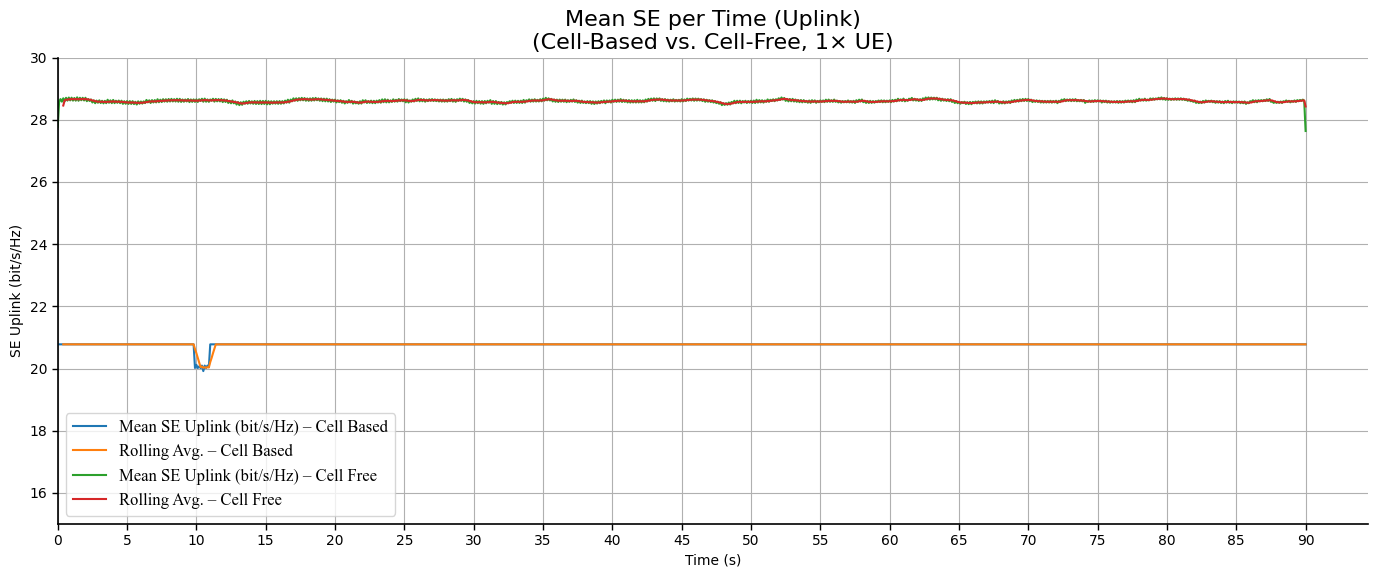

In [13]:
# --- Pré-processamento: converter Tempo para segundos ---
df_cb_1 = df_cb_1.copy()
df_cf_1_aggr = df_cf_1_aggr.copy()

df_cb_1["Time_s"] = df_cb_1["Time_ms"] / 1000.0
df_cf_1_aggr["Time_s"] = df_cf_1_aggr["Time_ms"] / 1000.0

df_cb_1["Mean_UL_SE_bit_per_s_Hz"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cb_1["Rolling Avg (bit/s/Hz)"] = df_cb_1["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].round(3)
df_cf_1_aggr["Rolling Avg (bit/s/Hz)"] = df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

# --- Figura ---
plt.figure(figsize=(14, 6))
ax = plt.gca()

# --- Estilo académico: Times New Roman + tamanhos ---
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14             # tamanho base
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# Linhas
sns.lineplot(x="Time_s", y="Mean_UL_SE_bit_per_s_Hz", data=df_cb_1, label="Mean SE Uplink (bit/s/Hz) – Cell Based", ax=ax)
sns.lineplot(x="Time_s", y="Rolling Avg (bit/s/Hz)", data=df_cb_1, label="Rolling Avg. – Cell Based", ax=ax)
sns.lineplot(x="Time_s", y="Mean_UL_SE_bit_per_s_Hz", data=df_cf_1_aggr, label="Mean SE Uplink (bit/s/Hz) – Cell Free", ax=ax)
sns.lineplot(x="Time_s", y="Rolling Avg (bit/s/Hz)", data=df_cf_1_aggr, label="Rolling Avg. – Cell Free", ax=ax)

# Títulos e rótulos
ax.set_title("Mean SE per Time (Uplink)\n(Cell-Based vs. Cell-Free, 1× UE)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

# Escalas: X em segundos, major ticks de 5s (equivalente aos 5000 ms)
ax.set_xlim(left=0)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(15,30)

# Escala Y ajustada automaticamente ao próximo múltiplo de 5
ymax = max(
    df_cb_1["Mean_UL_SE_bit_per_s_Hz"].max(skipna=True),
    df_cb_1["Rolling Avg (bit/s/Hz)"].max(skipna=True),
    df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].max(skipna=True),
    df_cf_1_aggr["Rolling Avg (bit/s/Hz)"].max(skipna=True),
)


# Sem grelha; apenas moldura nos eixos X e Y
ax.grid(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

# Legenda

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_cf_aggr_1x_seconds.pdf", dpi=300, bbox_inches="tight")
plt.show()


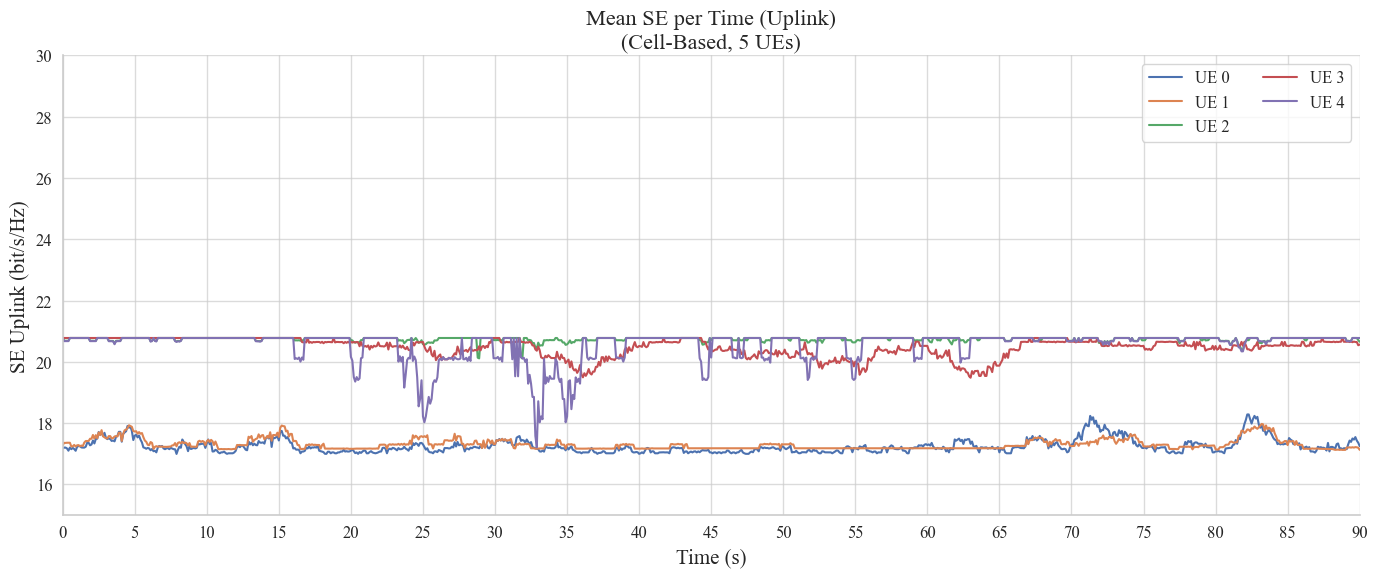

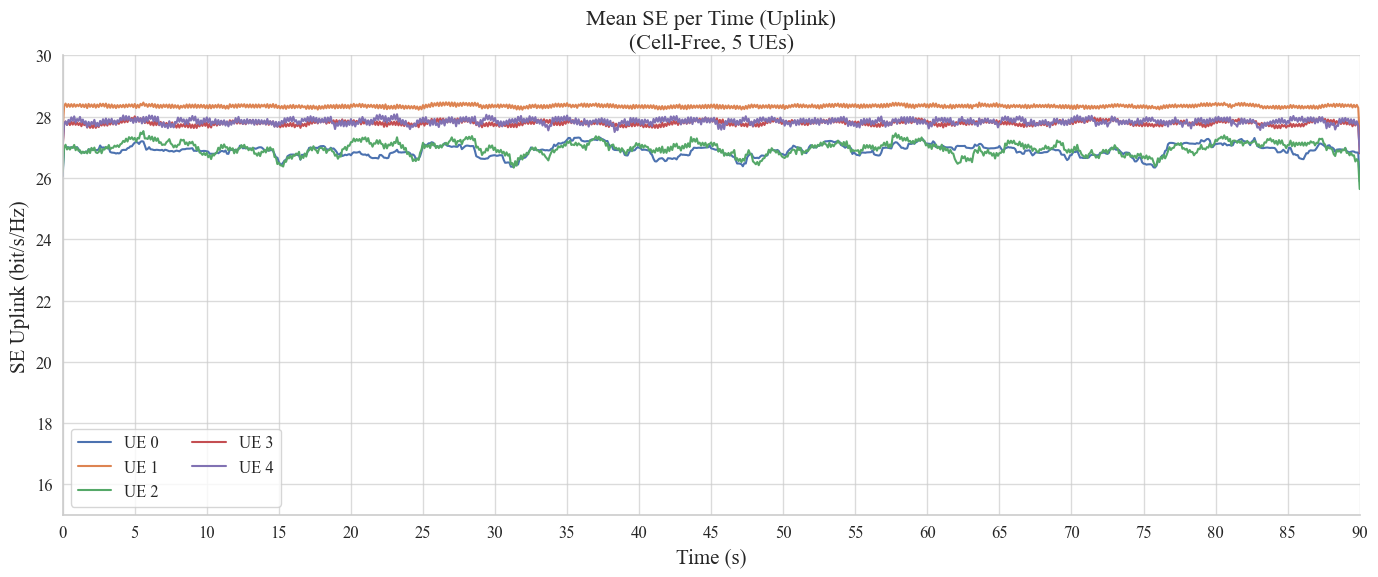

In [105]:

dfs_cb_5_sec = {}
for ue, df in dfs_cb_5.items():
    d = df.copy()
    d["Time_s"] = d["Time_ms"] / 1000.0
    d["Mean_UL_SE_bit_per_s_Hz"] = d["Mean_UL_SE_bit_per_s_Hz"].round(3)
    dfs_cb_5_sec[ue] = d

# Descobrir o ymax para escalar Y de forma limpa
ymax_cb = 0.0
for d in dfs_cb_5_sec.values():
    if not d["Mean_UL_SE_bit_per_s_Hz"].empty:
        ymax_cb = max(ymax_cb, d["Mean_UL_SE_bit_per_s_Hz"].max())

plt.figure(figsize=(14, 6))
ax = plt.gca()

for i, (ue, d) in enumerate(dfs_cb_5_sec.items()):
    sns.lineplot(
        x="Time_s", 
        y="Mean_UL_SE_bit_per_s_Hz", 
        data=d, 
        label=f"UE {i}",  # força 0–4
        ax=ax
    )

ax.set_title("Mean SE per Time (Uplink)\n(Cell-Based, 5 UEs)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

# Eixo X 0–90 s com major ticks de 5 s
ax.set_xlim(0, 90)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(15,30)

# Sem grelha; apenas moldura nos eixos X e Y
ax.grid(True, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_aggr_5x_seconds.pdf", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2) Cell-Free (5 UEs)
# =========================
# Converter Time_ms -> Time_s e arredondar
dfs_cf_5_aggr_sec = {}
for ue, df in dfs_cf_5_aggr.items():
    d = df.copy()
    d["Time_s"] = d["Time_ms"] / 1000.0
    d["Mean_UL_SE_bit_per_s_Hz"] = d["Mean_UL_SE_bit_per_s_Hz"].round(3)
    dfs_cf_5_aggr_sec[ue] = d

# Descobrir o ymax para escalar Y de forma limpa
ymax_cf = 0.0
for d in dfs_cf_5_aggr_sec.values():
    if not d["Mean_UL_SE_bit_per_s_Hz"].empty:
        ymax_cf = max(ymax_cf, d["Mean_UL_SE_bit_per_s_Hz"].max())

plt.figure(figsize=(14, 6))
ax = plt.gca()

for ue, d in dfs_cf_5_aggr_sec.items():
    sns.lineplot(x="Time_s", y="Mean_UL_SE_bit_per_s_Hz", data=d, label=f"UE {ue}", ax=ax)

ax.set_title("Mean SE per Time (Uplink)\n(Cell-Free, 5 UEs)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

# Eixo X 0–90 s com major ticks de 5 s
ax.set_xlim(0, 90)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(15,30)

# Sem grelha; apenas moldura nos eixos X e Y
ax.grid(True, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cf_aggr_5x_seconds.pdf", dpi=300, bbox_inches="tight")
plt.show()

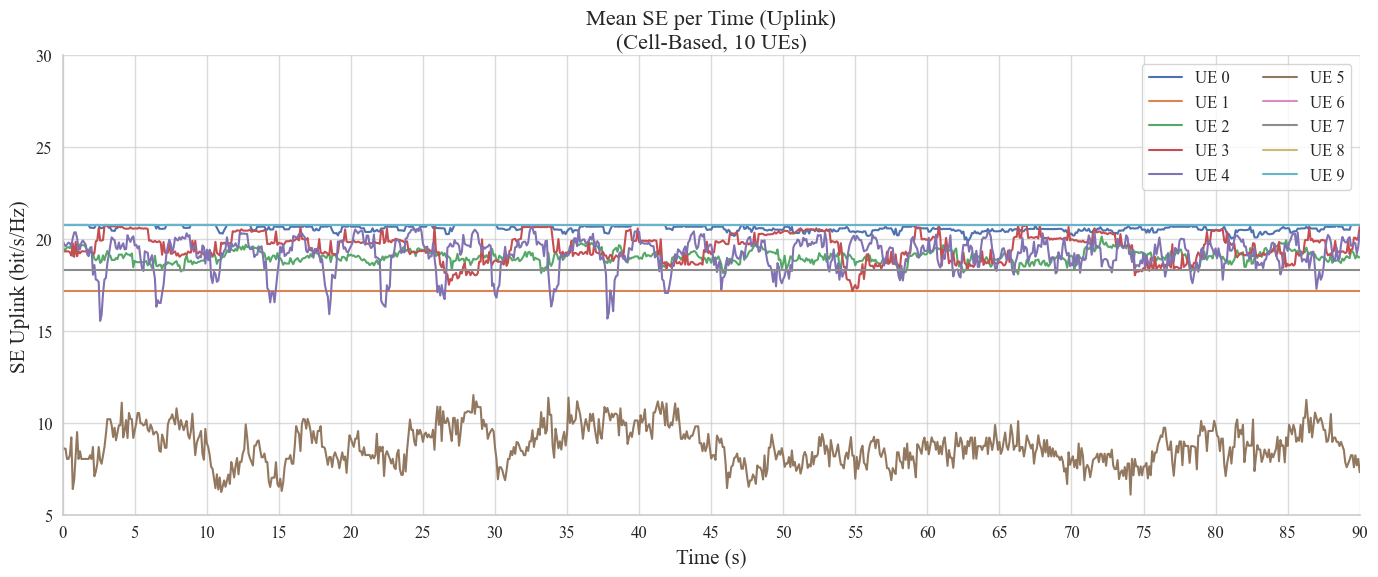

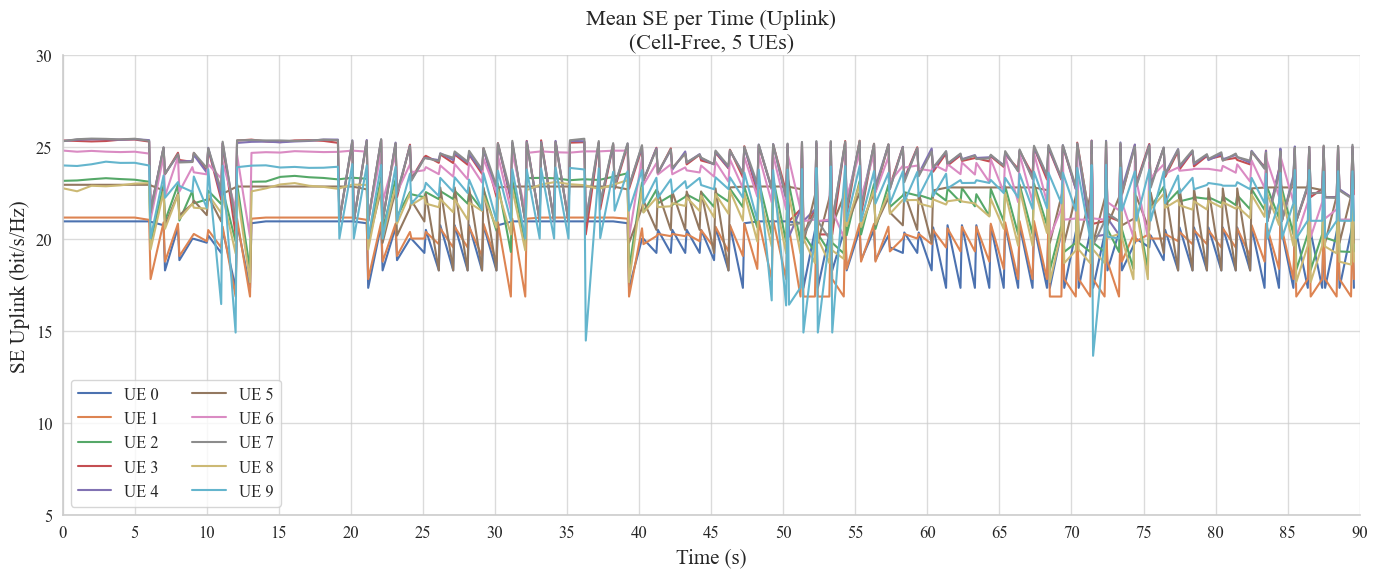

In [121]:

dfs_cb_10_sec = {}
for ue, df in dfs_cb_10.items():
    d = df.copy()
    d["Time_s"] = d["Time_ms"] / 1000.0
    d["Mean_UL_SE_bit_per_s_Hz"] = d["Mean_UL_SE_bit_per_s_Hz"].round(3)
    dfs_cb_10_sec[ue] = d

# Descobrir o ymax para escalar Y de forma limpa
ymax_cb = 0.0
for d in dfs_cb_10_sec.values():
    if not d["Mean_UL_SE_bit_per_s_Hz"].empty:
        ymax_cb = max(ymax_cb, d["Mean_UL_SE_bit_per_s_Hz"].max())

plt.figure(figsize=(14, 6))
ax = plt.gca()

for i, (ue, d) in enumerate(dfs_cb_10_sec.items()):
    sns.lineplot(
        x="Time_s", 
        y="Mean_UL_SE_bit_per_s_Hz", 
        data=d, 
        label=f"UE {i}",  # força 0–4
        ax=ax
    )

ax.set_title("Mean SE per Time (Uplink)\n(Cell-Based, 10 UEs)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

ax.set_xlim(0, 90)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(5,30)
ax.grid(True, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_aggr_10x_seconds.pdf", dpi=300, bbox_inches="tight")

plt.show()

# =========================
# 2) Cell-Free (5 UEs)
# =========================
# Converter Time_ms -> Time_s e arredondar
dfs_cf_10_aggr_sec = {}
for ue, df in dfs_cf_10_aggr.items():
    d = df.copy()
    d["Time_s"] = d["Time_ms"] / 1000.0
    d["Mean_UL_SE_bit_per_s_Hz"] = d["Mean_UL_SE_bit_per_s_Hz"].round(3)
    dfs_cf_10_aggr_sec[ue] = d

# Descobrir o ymax para escalar Y de forma limpa
ymax_cf = 0.0
for d in dfs_cf_10_aggr_sec.values():
    if not d["Mean_UL_SE_bit_per_s_Hz"].empty:
        ymax_cf = max(ymax_cf, d["Mean_UL_SE_bit_per_s_Hz"].max())

plt.figure(figsize=(14, 6))
ax = plt.gca()

for ue, d in dfs_cf_10_aggr_sec.items():
    sns.lineplot(x="Time_s", y="Mean_UL_SE_bit_per_s_Hz", data=d, label=f"UE {ue}", ax=ax)

ax.set_title("Mean SE per Time (Uplink)\n(Cell-Free, 5 UEs)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

ax.set_xlim(0, 90)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(5,30)
ax.grid(True, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cf_aggr_10x_seconds.pdf", dpi=300, bbox_inches="tight")
plt.show()

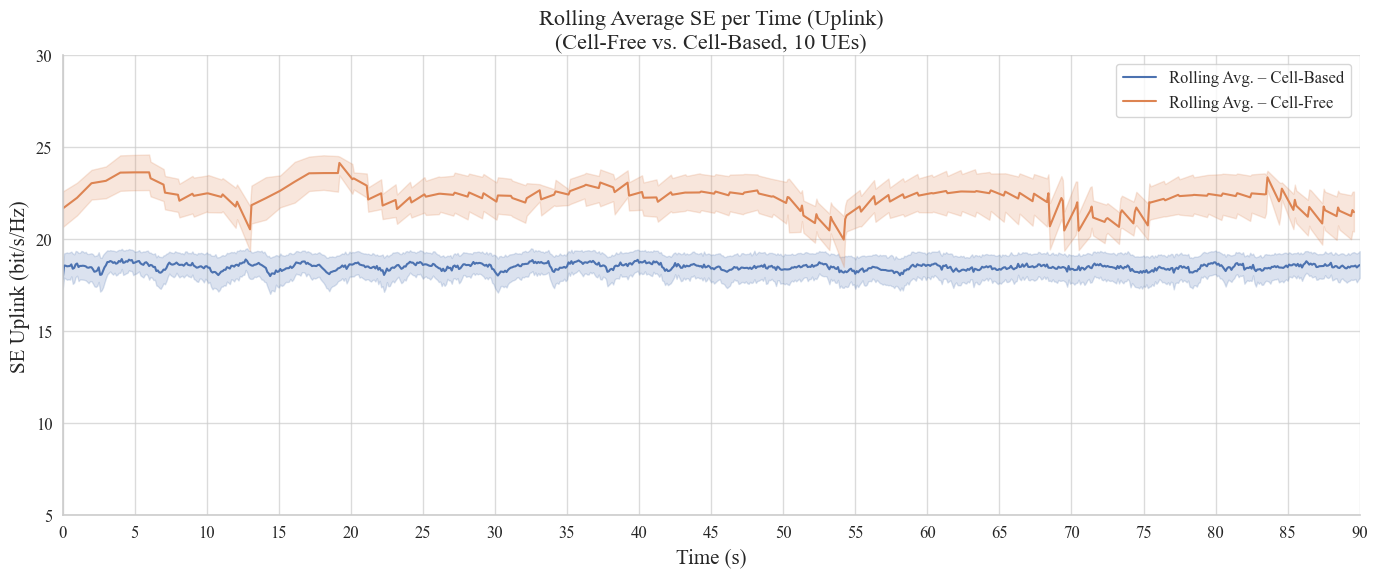

In [122]:
df_cb_10 = df_cb_10.copy()
df_cf_10_aggr = df_cf_10_aggr.copy()

df_cb_10["Time_s"] = df_cb_10["Time_ms"] / 1000.0
df_cf_10_aggr["Time_s"] = df_cf_10_aggr["Time_ms"] / 1000.0

df_cb_10["Mean_UL_SE_bit_per_s_Hz"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"]
df_cb_10["Rolling Avg (bits/s/Hz)"] = df_cb_10["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()

df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"] = df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"]
df_cf_10_aggr["Rolling Avg (bits/s/Hz)"] = df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5).mean()


# --- Figura ---
plt.figure(figsize=(14, 6))
ax = plt.gca()

sns.lineplot(x="Time_s", y="Rolling Avg (bits/s/Hz)", data=df_cb_10, label="Rolling Avg. – Cell-Based", ax=ax)
sns.lineplot(x="Time_s", y="Rolling Avg (bits/s/Hz)", data=df_cf_10_aggr, label="Rolling Avg. – Cell-Free", ax=ax)

ax.set_title("Rolling Average SE per Time (Uplink)\n(Cell-Free vs. Cell-Based, 10 UEs)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("SE Uplink (bit/s/Hz)")

# Eixo X 0–90 s com major ticks de 5 s
ax.set_xlim(0, 90)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_ylim(5,30)

# Sem grelha; apenas moldura nos eixos X e Y
ax.grid(False)
ax.grid(True, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)
ax.tick_params(axis="both", which="both", direction="out", length=4, width=1)

ax.legend(ncol=1)
plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_cf_rlng_avg_10x_seconds.pdf", dpi=300, bbox_inches="tight")
plt.show()

# BARPLOTS

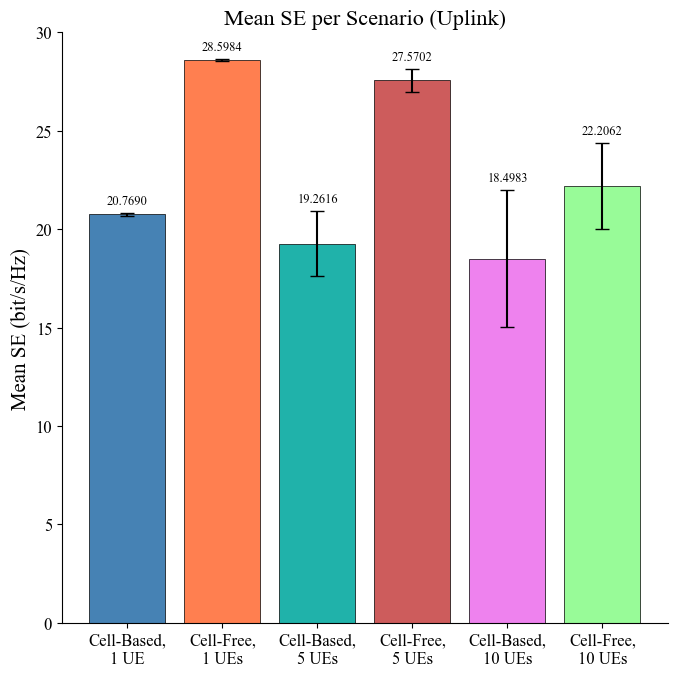

In [19]:


# Médias
mean_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_41 = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()

# Desvios padrão
std_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_41 = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].std()

# Lista de valores
mean_values = [
    mean_se_total_3,
    mean_se_total_61,
    mean_se_total_2,
    mean_se_total_51,

      mean_se_total_1,
    mean_se_total_41
]

std_values = [
    std_se_total_3,
    std_se_total_61,
    std_se_total_2,
    std_se_total_51,

        std_se_total_1,
    std_se_total_41
]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",

        "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs"
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, yerr=std_values, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean SE per Scenario (Uplink)")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Medium values on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + std_values[i] + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_cf_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

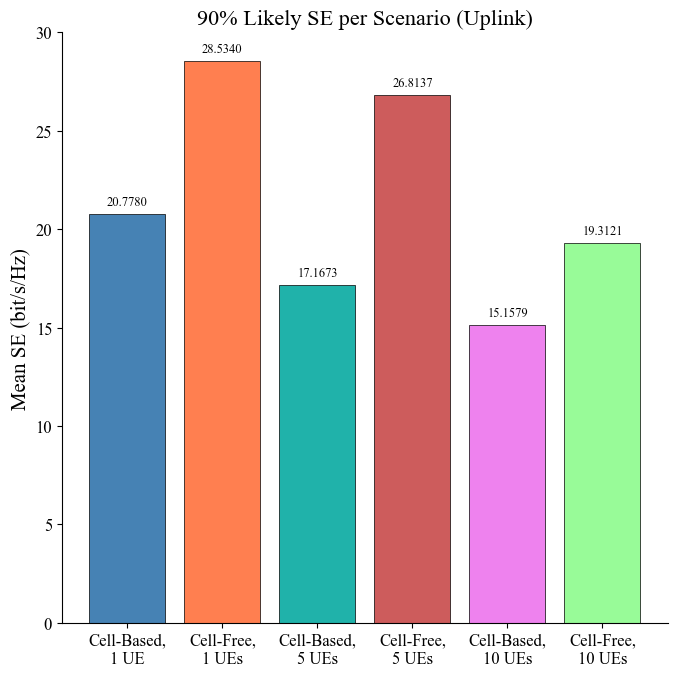

In [20]:


# quantis
p10_cf_1_aggr = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_5_aggr = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_10_aggr = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_1 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_5 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_10 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)

# Lista de valores
mean_values = [
    p10_cb_1,
    p10_cf_1_aggr,
    p10_cb_5,
    p10_cf_5_aggr,

        p10_cb_10,
    p10_cf_10_aggr
]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",

        "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs"
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("90% Likely SE per Scenario (Uplink)")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

# Medium values on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/mean_se_90_uplink_cb_cf_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

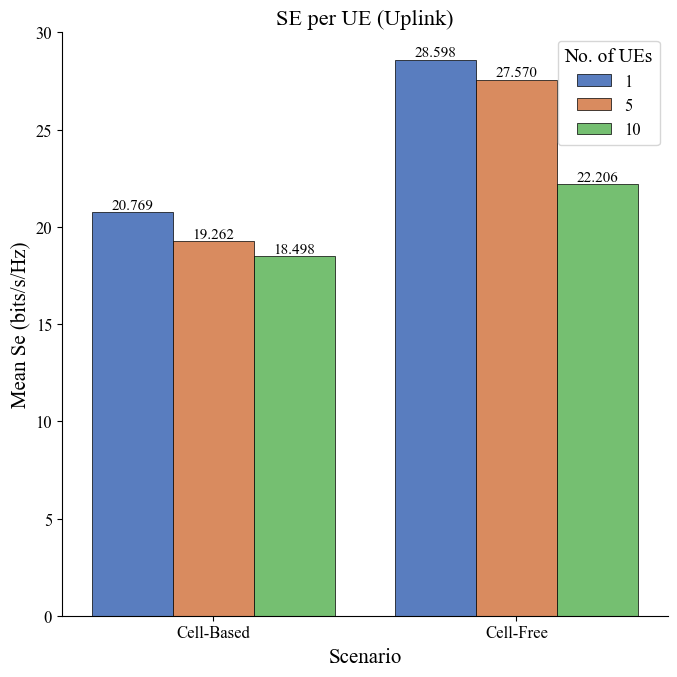

In [18]:
# Criar DataFrame (mantém-se igual)
data = {
    "Nº de UEs": [1, 1, 5, 5, 10, 10],
    "Cenário": ["Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",],
    "SE_total": [
        df_cb_1["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_5["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_10["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].mean()
    ]
}

df_plot = pd.DataFrame(data)

# Plot com associação por cenário
plt.figure(figsize=(7, 7))
sns.barplot(
    x="Cenário",       # eixo X agora é o cenário
    y="SE_total",
    hue="Nº de UEs",   # cores distinguem nº de UEs
    data=df_plot,
    palette="muted",
    edgecolor="black",
    linewidth=0.5,
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.title("SE per UE (Uplink)")
plt.ylabel("Mean Se (bits/s/Hz)")
plt.xlabel("Scenario")
plt.legend(title="No. of UEs", loc="best")
plt.ylim(0, 30)

# --- Adicionar valores em cima de cada barra ---
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",   # ajustei para 3 casas decimais
            ha="center", va="bottom",
            fontsize=11, fontfamily="Times New Roman"
        )

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()


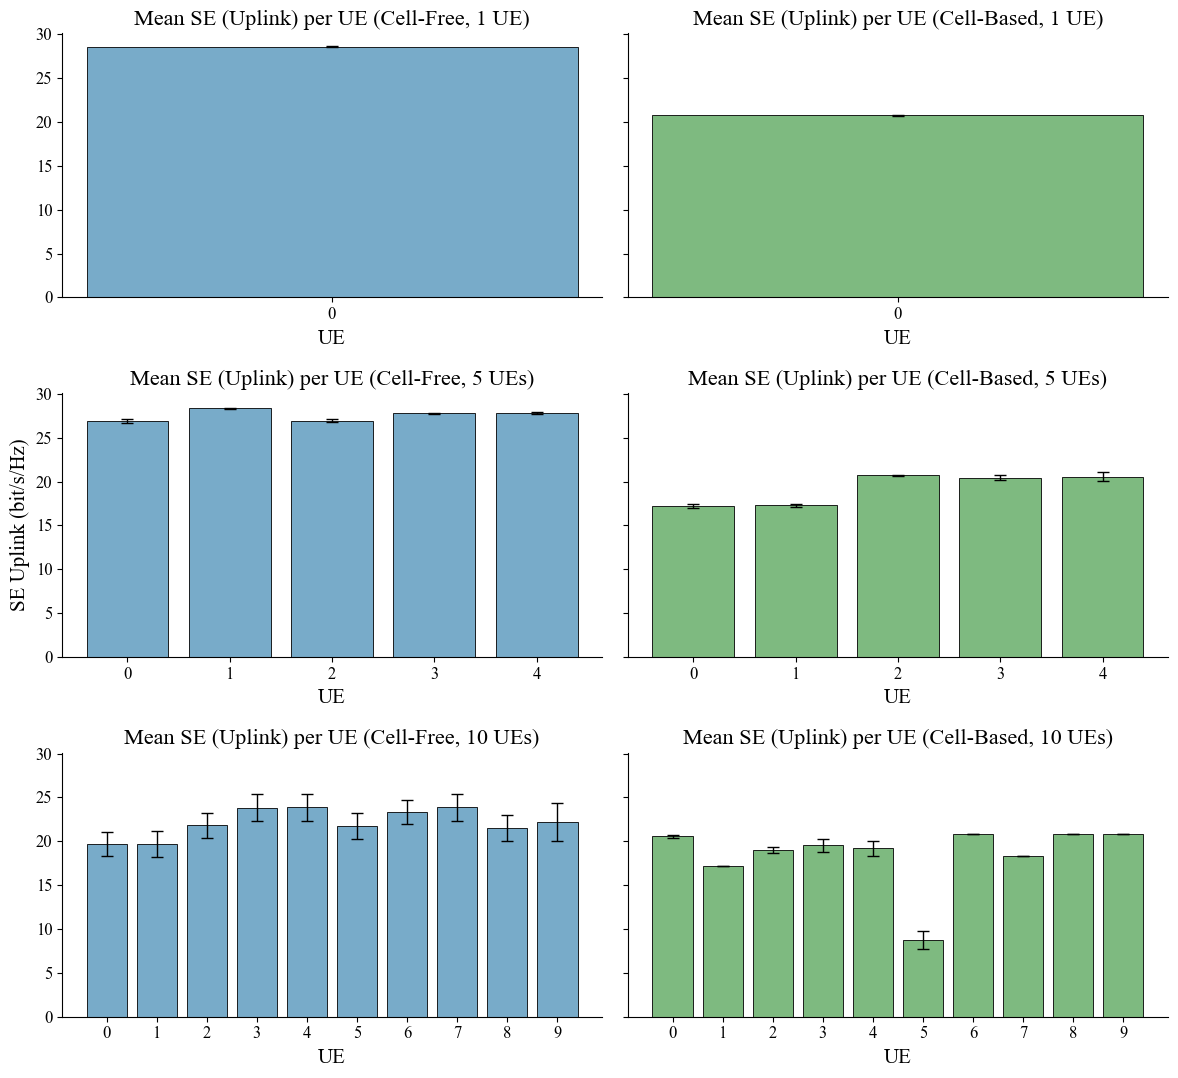

In [21]:
# CF 10x UEs
df_means_cf_10 = (df_cf_10_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 10x UEs
df_means_cb_10 = (df_cb_10
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CF 5x UEs
df_means_cf_5 = (df_cf_5_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 5x UEs
df_means_cb_5 = (df_cb_5
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())


# CF 1x UEs
df_means_cf_1 = (df_cf_1_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 1x UEs
df_means_cb_1 = (df_cb_1
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

fig, axes = plt.subplots(3, 2, figsize=(12,11), sharey=True)

configs = [
    (df_means_cf_1, df_means_cb_1, "1 UE"),
    (df_means_cf_5, df_means_cb_5, "5 UEs"),
    (df_means_cf_10, df_means_cb_10, "10 UEs")
]

colors = {"CF": "#6baed6", "CB": "#74c476"}

for row, (df_cf, df_cb, label) in enumerate(configs):
    # --- CF ---
    ax_cf = axes[row, 0]
    sns.barplot(data=df_cf, x="UE_ID", y="mean",
                color=colors["CF"], edgecolor="black", linewidth=0.6,
                errorbar=None, ax=ax_cf)
    ax_cf.errorbar(x=np.arange(len(df_cf)), y=df_cf["mean"], yerr=df_cf["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cf.set_title(f"Mean SE (Uplink) per UE (Cell-Free, {label})")
    ax_cf.set_xlabel("UE")
    if row == 1:  # só na linha do meio mostrar ylabel
        ax_cf.set_ylabel("SE Uplink (bit/s/Hz)")
    else:
        ax_cf.set_ylabel("")
    ax_cf.spines["top"].set_visible(False)
    ax_cf.spines["right"].set_visible(False)
    ax_cf.grid(False)

    # --- CB ---
    ax_cb = axes[row, 1]
    sns.barplot(data=df_cb, x="UE_ID", y="mean",
                color=colors["CB"], edgecolor="black", linewidth=0.6,
                errorbar=None, ax=ax_cb)
    ax_cb.errorbar(x=np.arange(len(df_cb)), y=df_cb["mean"], yerr=df_cb["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cb.set_title(f"Mean SE (Uplink) per UE (Cell-Based, {label})")
    ax_cb.set_xlabel("UE")
    ax_cb.set_ylabel("")
    ax_cb.spines["top"].set_visible(False)
    ax_cb.spines["right"].set_visible(False)
    ax_cb.grid(False)
    ax_cb.set_xticks(np.arange(len(df_cb)))
    ax_cb.set_xticklabels([str(i) for i in range(len(df_cb))])

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_total_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

# BOXPLOTS

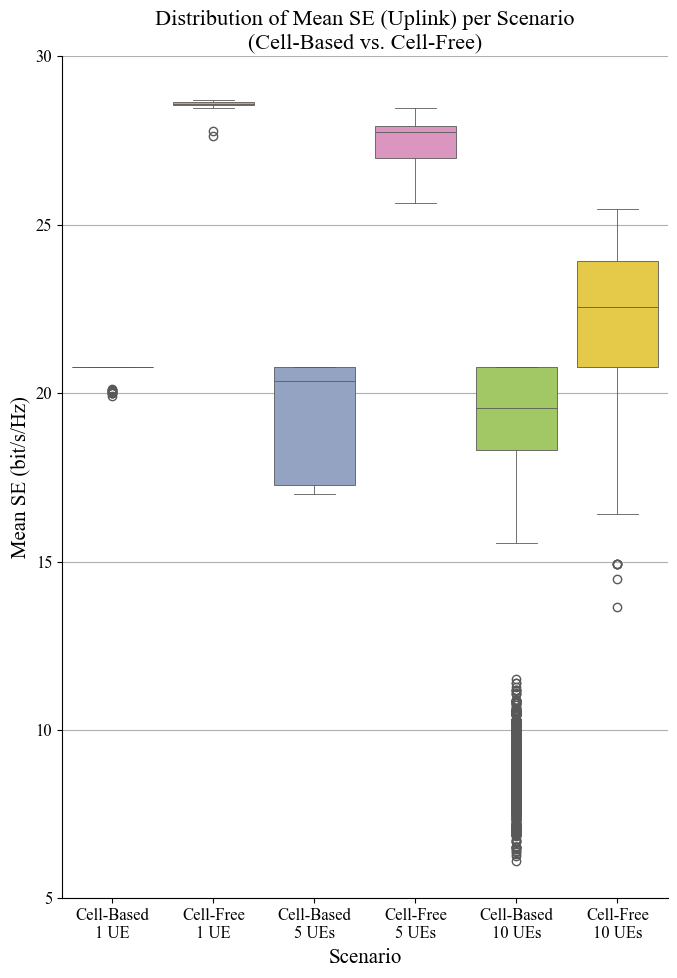

In [28]:
df_cb_10["Scenario"] = "Cell-Based\n10 UEs"
df_cf_10_aggr["Scenario"] = "Cell-Free\n10 UEs"
df_cb_5["Scenario"] = "Cell-Based\n5 UEs"
df_cf_5_aggr["Scenario"] = "Cell-Free\n5 UEs"
df_cb_1["Scenario"] = "Cell-Based\n1 UE"
df_cf_1_aggr["Scenario"] = "Cell-Free\n1 UE"

df_all = pd.concat([ df_cb_1, df_cf_1_aggr, df_cb_5, df_cf_5_aggr, df_cb_10, df_cf_10_aggr], ignore_index=True)

plt.figure(figsize=(7,10))
# Tbm pode ser feito com sns.boxplot
sns.boxplot(
    x="Scenario",
    y="Mean_UL_SE_bit_per_s_Hz",
    data=df_all,
    hue="Scenario",
    palette="Set2",
    linewidth=0.6
)
plt.title("Distribution of Mean SE (Uplink) per Scenario\n(Cell-Based vs. Cell-Free)")
plt.xlabel("Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(5, 30)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("figs/mean_se_boxplot_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()

#### outliers removal

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_18100\1851873054.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drop_outliers_iqr, k=1.5))


                   before  after  removed
Scenario                                 
Cell-Based 1 UE       899    899        0
Cell-Based 10 UEs    9010   8109      901
Cell-Based 5 UEs     4505   4505        0
Cell-Free 1 UE        901    899        2
Cell-Free 10 UEs     1736   1730        6
Cell-Free 5 UEs      4505   4505        0


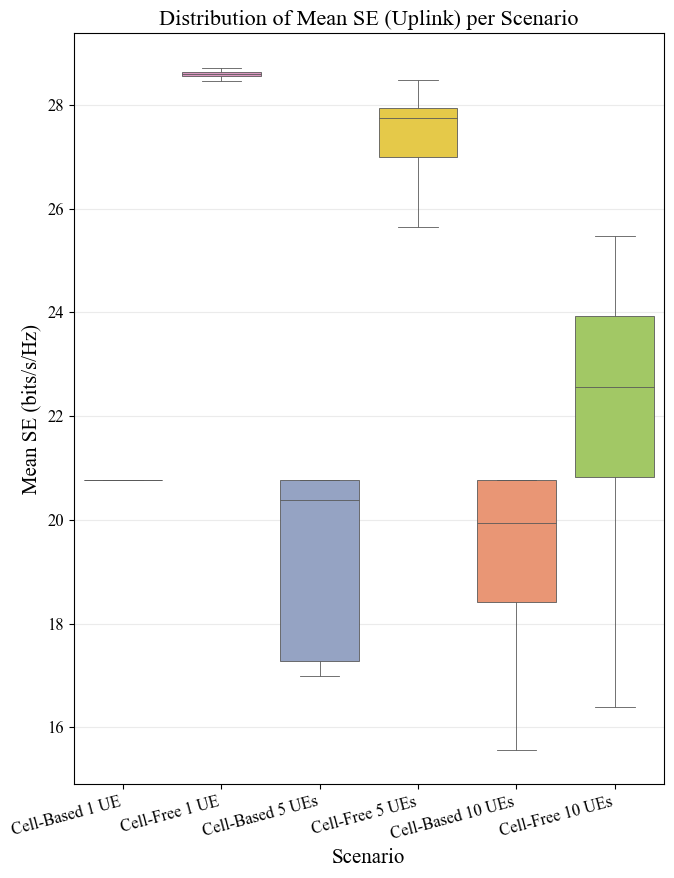

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

order = ['Cell-Based 1 UE','Cell-Free 1 UE',
         'Cell-Based 5 UEs','Cell-Free 5 UEs',
         'Cell-Based 10 UEs','Cell-Free 10 UEs']


# 1) Empilha os 6 cenários num dataframe longo
df_long = pd.concat([
    df_cb_1.assign(Scenario="Cell-Based 1 UE")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_1_aggr.assign(Scenario="Cell-Free 1 UE")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cb_5.assign(Scenario="Cell-Based 5 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_5_aggr.assign(Scenario="Cell-Free 5 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cb_10.assign(Scenario="Cell-Based 10 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_10_aggr.assign(Scenario="Cell-Free 10 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
], ignore_index=True).rename(columns={"Mean_UL_SE_bit_per_s_Hz": "value"})

# 2) Remover outliers por IQR (1.5×) em cada cenário
def drop_outliers_iqr(g, k=1.5):
    q1 = g["value"].quantile(0.25)
    q3 = g["value"].quantile(0.75)
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        return g
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return g[(g["value"] >= lo) & (g["value"] <= hi)]

before = df_long.groupby("Scenario")["value"].size()

df_clean = (df_long
            .groupby("Scenario", group_keys=False)
            .apply(drop_outliers_iqr, k=1.5))

after = df_clean.groupby("Scenario")["value"].size()
print(pd.concat([before.rename("before"), after.rename("after"),
                 (before-after).rename("removed")], axis=1))

# 3) Boxplot sem outliers visuais
plt.figure(figsize=(7, 9))
ax = sns.boxplot(data=df_clean, 
                 x="Scenario", 
                 y="value", 
                 hue="Scenario",
                 palette="Set2",
                 linewidth=0.6,
                 order=order, 
                 whis=1.5, 
                 showfliers=False)
ax.set_title("Distribution of Mean SE (Uplink) per Scenario")
ax.set_xlabel("Scenario"); ax.set_ylabel("Mean SE (bits/s/Hz)")
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("figs/mean_se_boxplot_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()

# LINE PLOTS

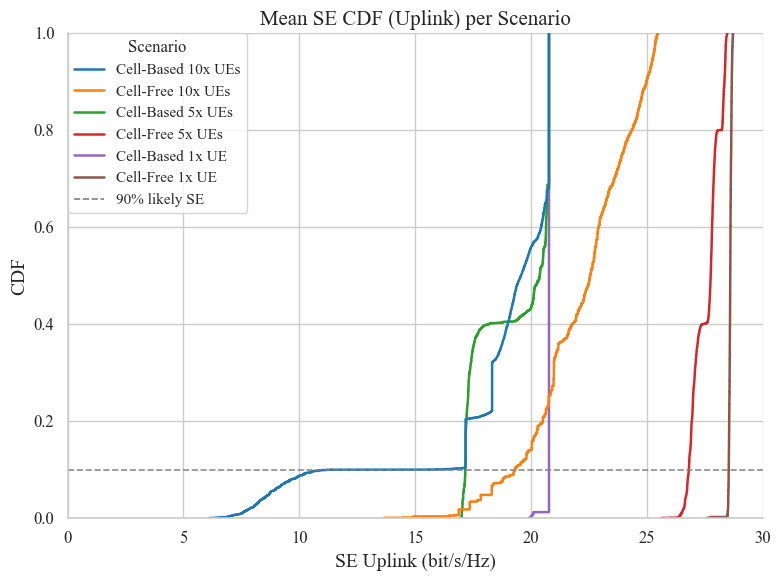

In [138]:
df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10_aggr["Scenario"] = "Cell-Free 10x UEs"
df_cb_5["Scenario"] = "Cell-Based 5x UEs"
df_cf_5_aggr["Scenario"] = "Cell-Free 5x UEs"
df_cb_1["Scenario"] = "Cell-Based 1x UE"
df_cf_1_aggr["Scenario"] = "Cell-Free 1x UE"

dfs_to_plot = [
    df_cb_10[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_10_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_5[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_5_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_1[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_1_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
]

df_all = pd.concat(dfs_to_plot, ignore_index=True) 
df_all = df_all.dropna(subset=["Mean_UL_SE_bit_per_s_Hz"]).copy()

order = [
    "Cell-Based 10x UEs",
    "Cell-Free 10x UEs",
    "Cell-Based 5x UEs",
    "Cell-Free 5x UEs",
    "Cell-Based 1x UE",
    "Cell-Free 1x UE",
]

# paleta consistente (6 cores)
pal = sns.color_palette("tab10", n_colors=len(order))
palette_map = {name: pal[i] for i, name in enumerate(order)}

plt.figure(figsize=(8, 6))
ax = sns.ecdfplot(
    data=df_all,
    x="Mean_UL_SE_bit_per_s_Hz",
    hue="Scenario",
    hue_order=order,
    palette=palette_map,
    linewidth=1.8,
    legend=False  # vamos criar a legenda manualmente
)

# linha de referência 90%-likely (y=0.1)
y_ref = 0.1
ref_line = ax.axhline(y=y_ref, ls="--", lw=1.2, color="gray", alpha=0.9)

# títulos e eixos
ax.set_title("Mean SE CDF (Uplink) per Scenario")
ax.set_xlabel("SE Uplink (bit/s/Hz)")
ax.set_ylabel("CDF")
ax.set_xlim(0, 30)

# estilo (moldura só X/Y)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)

# legenda manual (todas as curvas + linha de referência)
handles = [Line2D([0], [0], color=palette_map[name], lw=1.8) for name in order]
labels = order + ["90% likely SE"]
handles.append(Line2D([0], [0], color="gray", lw=1.2, ls="--"))

ax.legend(
    handles, labels,
    title="Scenario",
    loc="upper left",
    borderaxespad=0.,
)

plt.tight_layout()
plt.savefig("figs/mean_se_cdf.pdf", dpi=300, bbox_inches="tight")
plt.show()

                    before  after  removed
Scenario                                  
Cell-Based 10x UEs    9010   8109      901
Cell-Based 1x UE       899    899        0
Cell-Based 5x UEs     4505   4505        0
Cell-Free 10x UEs     1736   1730        6
Cell-Free 1x UE        901    899        2
Cell-Free 5x UEs      4505   4505        0


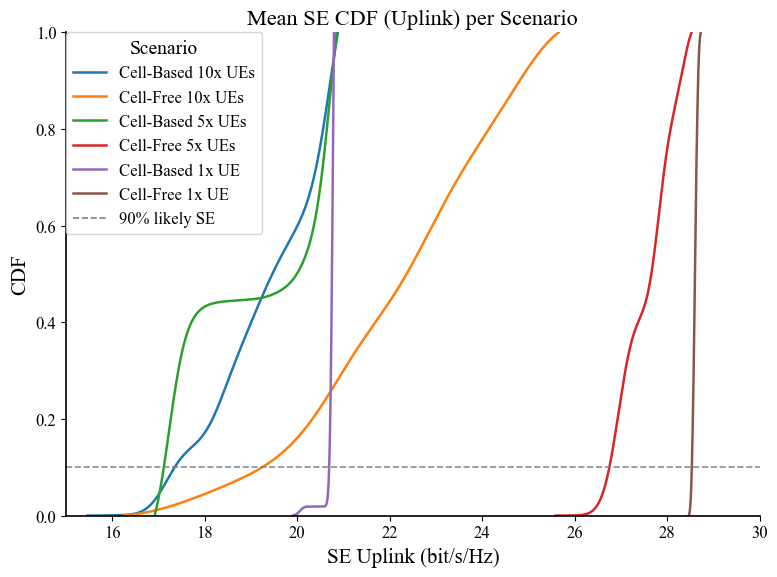

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- 1) Empilhar dados como no teu snippet ---
df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10_aggr["Scenario"] = "Cell-Free 10x UEs"
df_cb_5["Scenario"]  = "Cell-Based 5x UEs"
df_cf_5_aggr["Scenario"]  = "Cell-Free 5x UEs"
df_cb_1["Scenario"]  = "Cell-Based 1x UE"
df_cf_1_aggr["Scenario"]  = "Cell-Free 1x UE"

dfs_to_plot = [
    df_cb_10[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_10_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_5[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_5_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_1[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_1_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
]
df_all = pd.concat(dfs_to_plot, ignore_index=True)
df_all = df_all.dropna(subset=["Mean_UL_SE_bit_per_s_Hz"]).copy()


def smooth_cdf(values, bins=400, sigma_bins=3):
    """ECDF suave via histograma e convolução gaussiana."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([]), np.array([])
    xmin, xmax = v.min(), v.max()
    # margem ligeira para não “cortar” caudas
    pad = 0.02 * (xmax - xmin if xmax > xmin else 1.0)
    edges = np.linspace(xmin - pad, xmax + pad, bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=False)
    # kernel gaussiano em “nº de bins”
    khalf = int(4 * sigma_bins)
    kx = np.arange(-khalf, khalf + 1)
    kernel = np.exp(-0.5 * (kx / float(sigma_bins))**2)
    kernel /= kernel.sum()
    smooth_counts = np.convolve(counts, kernel, mode="same")
    cdf = np.cumsum(smooth_counts) / np.sum(smooth_counts)
    x = 0.5 * (edges[:-1] + edges[1:])
    return x, cdf


# --- 2) Remoção de outliers por cenário (IQR 1.5×) ---
k = 1.5
g = df_all.groupby("Scenario")["Mean_UL_SE_bit_per_s_Hz"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
lo, hi = q1 - k*iqr, q3 + k*iqr
mask = ((df_all["Mean_UL_SE_bit_per_s_Hz"] >= lo) &
        (df_all["Mean_UL_SE_bit_per_s_Hz"] <= hi)) | (iqr == 0)
df_no = df_all[mask].copy()

# (opcional) relatório do que foi removido
print(
    pd.concat(
        [
            df_all.groupby("Scenario").size().rename("before"),
            df_no.groupby("Scenario").size().rename("after")
        ],
        axis=1
    ).assign(removed=lambda d: d["before"] - d["after"])
)

# --- 3) ECDF com outliers removidos ---
order = [
    "Cell-Based 10x UEs",
    "Cell-Free 10x UEs",
    "Cell-Based 5x UEs",
    "Cell-Free 5x UEs",
    "Cell-Based 1x UE",
    "Cell-Free 1x UE",
]

pal = plt.get_cmap("tab10").colors
palette_map = {name: pal[i] for i, name in enumerate(order)}

plt.figure(figsize=(8,6))
ax = plt.gca()
for name in order:
    x, y = smooth_cdf(df_no.loc[df_no["Scenario"] == name, "Mean_UL_SE_bit_per_s_Hz"],
                      bins=500, sigma_bins=30)   # ↑ sigma_bins = curva mais “suave”
    if x.size:
        ax.plot(x, y, lw=1.8, color=palette_map[name], label=name)

# linha de referência (ex.: 10% inferior -> y=0.1)
y_ref = 0.1
ax.axhline(y=y_ref, ls="--", lw=1.2, color="gray", alpha=0.9)

ax.set_title("Mean SE CDF (Uplink) per Scenario")
ax.set_xlabel("SE Uplink (bit/s/Hz)")
ax.set_ylabel("CDF")
ax.set_xlim(15, 30)
ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)

# legenda manual
handles = [Line2D([0], [0], color=palette_map[name], lw=1.8) for name in order]
labels = order + ["90% likely SE"]
handles.append(Line2D([0], [0], color="gray", lw=1.2, ls="--"))

ax.legend(handles, labels, title="Scenario", loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.savefig("figs/mean_se_cdf_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_6748\1051074289.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_6748\1051074289.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
C:\Users\Ana Gou

  Scenario  UEs      Jain  Jain_mean_t    Jain_std_t
0       CB    1  1.000000     1.000000  0.000000e+00
2       CB    5  0.992954     0.992803  9.101467e-04
4       CB   10  0.966573     0.965942  5.710414e-03
1  CF-Aggr    1  1.000000     1.000000  5.233642e-18
3  CF-Aggr    5  0.999597     0.999582  1.136253e-04
5  CF-Aggr   10  0.995308     0.994162  3.175630e-03


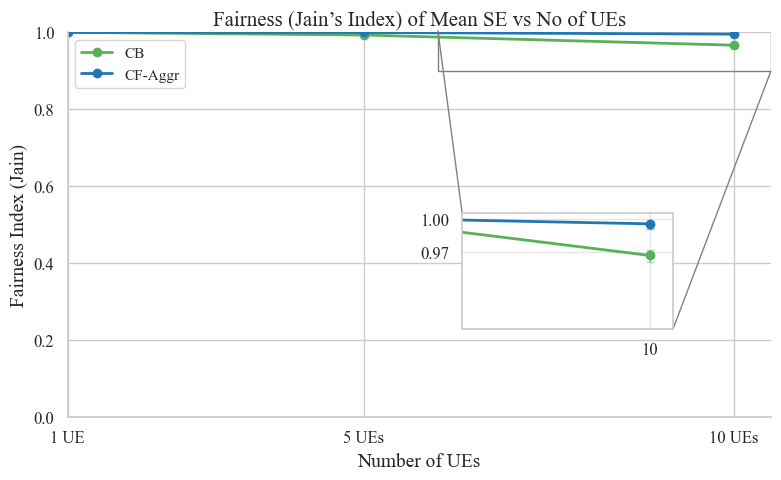

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# --- helpers ---------------------------------------------------------------
def to_df(x):
    """Se vier um dict de DFs por UE, achata para um único DataFrame,
    sem colidir com uma coluna UE_ID já existente."""
    if isinstance(x, dict):
        # concat com nome de nível que não colida com colunas existentes
        df = pd.concat(x, names=["UE"]).reset_index(level=0).rename(columns={"level_0": "UE"})
        # se já existe UE_ID nos DFs internos, descarta a auxiliar
        if "UE_ID" in df.columns:
            df = df.drop(columns=["UE"])
        else:
            # caso contrário, usa a chave do dict como UE_ID
            df = df.rename(columns={"UE": "UE_ID"})
        return df.reset_index(drop=True)
    return x.copy()

def jain_index(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.isclose((x**2).sum(), 0):
        return np.nan
    return (x.sum()**2) / (len(x) * (x**2).sum())

def fairness_for_df(df):
    """Jain sobre as *médias por UE* (fairness entre utilizadores)."""
    per_ue_mean = (df.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
                     .mean()
                     .dropna()
                     .values)
    return jain_index(per_ue_mean)

def fairness_time_stats(df):
    """(opcional) Jain por instante -> média e std no tempo (para erro/banda)."""
    per_t = (df.groupby("Time_ms")
               .apply(lambda g: jain_index(g.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"].mean()))
               .dropna())
    return per_t.mean(), per_t.std()

CB_1   = to_df(df_cb_1)
CFA_1  = to_df(df_cf_1_aggr)
CB_5   = to_df(df_cb_5)
CFA_5  = to_df(df_cf_5_aggr)
CB_10  = to_df(df_cb_10)
CFA_10 = to_df(dfs_cf_10_aggr) 

datasets = {
    ("CB",      1): CB_1,
    ("CF-Aggr", 1): CFA_1,
    ("CB",      5): CB_5,   
    ("CF-Aggr", 5): CFA_5,
    ("CB",     10): CB_10,  
    ("CF-Aggr",10): CFA_10,
}

# --- tabela com Jain por cenário e nº de UEs --------------------------------
rows = []
for (scenario, nues), df in datasets.items():
    if df.empty: 
        continue
    j = fairness_for_df(df)
    mu, sd = fairness_time_stats(df)  # opcional (erro temporal)
    rows.append({"Scenario": scenario, "UEs": nues, "Jain": j, "Jain_mean_t": mu, "Jain_std_t": sd})

fair = pd.DataFrame(rows).sort_values(["Scenario","UEs"])
print(fair)

# --- plot tipo o do paper: linhas por cenário vs nº de UEs ------------------
plt.figure(figsize=(8,5))
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 13
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

palette = {"CB":(87/255, 178/255, 87/255), "CF-Aggr":"tab:blue",}

for scen, sub in fair.groupby("Scenario"):
    sub = sub.sort_values("UEs")
    # linha principal (Jain calculado sobre médias por UE)
    plt.plot(sub["UEs"], sub["Jain"], marker="o", lw=2, label=scen, color=palette.get(scen, None))
    # (opcional) barras de erro usando variação temporal do Jain
    if sub["Jain_std_t"].notna().any():
        plt.errorbar(sub["UEs"], sub["Jain_mean_t"], yerr=sub["Jain_std_t"],
                     fmt="none", ecolor=palette.get(scen, None), alpha=0.5, capsize=3)



plt.ylim(0, 1.0)
plt.xlim(1,10.5)
plt.title("Fairness (Jain’s Index) of Mean SE vs No of UEs")
plt.xlabel("Number of UEs")
plt.ylabel("Fairness Index (Jain)")
plt.xticks([1,5,10], ["1 UE","5 UEs","10 UEs"])
plt.legend(title=None, loc="best")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)

# criar inset (janela de zoom)
axins = inset_axes(ax, width="60%", height="60%", loc="upper left",
                   bbox_to_anchor=(0.55,0.05,0.5,0.5), bbox_transform=ax.transAxes)

# redesenhar os mesmos dados dentro do inset
for scen, sub in fair.groupby("Scenario"):
    sub = sub.sort_values("UEs")
    axins.plot(sub["UEs"], sub["Jain"], marker="o", lw=2,
               label=scen, color=palette.get(scen, None))
    if sub["Jain_std_t"].notna().any():
        axins.errorbar(sub["UEs"], sub["Jain_mean_t"], yerr=sub["Jain_std_t"],
                       fmt="none", ecolor=palette.get(scen, None),
                       alpha=0.5, capsize=3)

# limites da região de zoom (ajusta consoante os teus dados)
axins.set_xlim(6, 10.5)       # zoom nos ~10 UEs
axins.set_ylim(0.90, 1.005)   # zona perto de Jain=1

# remover ticks desnecessários para ficar mais limpo
axins.set_xticks([10])
axins.set_yticks([0.97, 1.0])

# ligar inset à região original
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.grid(False, alpha=0.5)
plt.tight_layout()
plt.savefig("figs/mean_jians_index_cdf.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_6748\3579321956.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


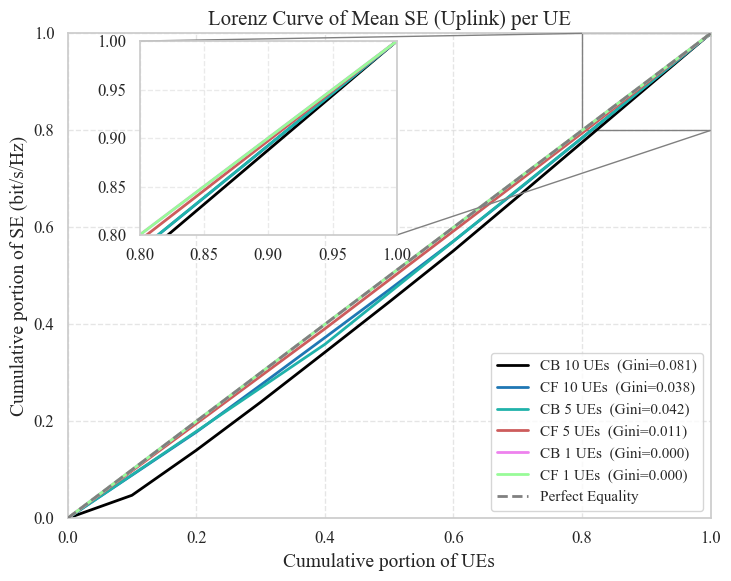

In [192]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# --- helpers ----------------------------------------------------------------
def to_df(x):
    """Se vier um dict de DFs por UE, achata para um único DataFrame,
    sem colidir com uma coluna UE_ID já existente."""
    if isinstance(x, dict):
        # concat com nome de nível que não colida com colunas existentes
        df = pd.concat(x, names=["UE"]).reset_index(level=0).rename(columns={"level_0": "UE"})
        # se já existe UE_ID nos DFs internos, descarta a auxiliar
        if "UE_ID" in df.columns:
            df = df.drop(columns=["UE"])
        else:
            # caso contrário, usa a chave do dict como UE_ID
            df = df.rename(columns={"UE": "UE_ID"})
        return df.reset_index(drop=True)
    return x.copy()

def normalize_se_col(df):
    """Garante que existe 'Mean_UL_SE_bit_per_s_Hz'."""
    df = df.copy()
    if "Mean_UL_SE_bit_per_s_Hz" not in df.columns and "SE_total_bit_per_s_Hz" in df.columns:
        df.rename(columns={"SE_total_bit_per_s_Hz":"Mean_UL_SE_bit_per_s_Hz"}, inplace=True)
    return df

def per_ue_mean_se(df):
    """SE MÉDIA por UE (fairness entre utilizadores)."""
    df = normalize_se_col(to_df(df))
    se = (df.groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .mean()
            .clip(lower=0)              # garantir não-negativo
            .sort_values()
            .to_numpy())
    return se

def gini_from_values(x):
    """Índice de Gini para vetor não-negativo (0=perfeito, 1=desigualdade total)."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    if np.allclose(x, 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cumx = np.cumsum(x)
    # fórmula vetorizada robusta
    g = (n + 1 - 2 * (cumx / cumx[-1]).sum()) / n
    return float(g)

def lorenz_curve_points(x):
    """Devolve (pop_share, se_share) já incluindo o (0,0) e o (1,1)."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0, None)
    x = np.sort(x)
    n = x.size
    if n == 0 or np.allclose(x.sum(), 0):
        return np.array([0,1]), np.array([0,1])
    cumx = np.cumsum(x)
    se_share = np.concatenate([[0], cumx / cumx[-1]])
    pop_share = np.linspace(0, 1, n+1)
    return pop_share, se_share

# --- dados: escolhe os de 10 UEs (ajusta nomes conforme os teus objetos) ----
CB_10  = df_cb_10
CFA_10 = dfs_cf_10_aggr

CB_5  = df_cb_5
CFA_5 = df_cf_5_aggr

CB_1  = df_cb_1
CFA_1 = df_cf_1_aggr

datasets = {
    "CB 10 UEs":  CB_10,
    "CF 10 UEs": CFA_10,
    "CB 5 UEs":  CB_5,
    "CF 5 UEs": CFA_5,
    "CB 1 UEs":  CB_1,
    "CF 1 UEs": CFA_1,
}

# --- calcular SE por UE, Gini e pontos da Lorenz ----------------------------
curves = {}
for name, df in datasets.items():
    se_vec = per_ue_mean_se(df)
    pop_share, se_share = lorenz_curve_points(se_vec)
    gini = gini_from_values(se_vec)
    curves[name] = {"pop": pop_share, "se": se_share, "gini": gini, "n": len(se_vec)}

# --- plot -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5,6))

# curvas primeiro
colors = {"CB 10 UEs":"black", "CF 10 UEs":"tab:blue", "CF 10 UEs (Aggr)":"tab:red",
          "CB 5 UEs":"lightseagreen", "CF 5 UEs":"indianred", "CF 5 UEs (Aggr)":"gold",
          "CB 1 UEs":"violet", "CF 1 UEs":"palegreen", "CF 1 UEs (Aggr)":"gold"}

for name, c in curves.items():
    ax.plot(c["pop"], c["se"], lw=2,
            label=f"{name}  (Gini={c['gini']:.3f})",
            color=colors.get(name, None))
    ax.scatter([c["pop"][-1]], [c["se"][-1]], s=12, color=colors.get(name, None))

# linha de igualdade perfeita por cima
ax.plot([0,1], [0,1], ls="--", lw=2, color="gray",
        label="Perfect Equality", zorder=10)

ax.set_title("Lorenz Curve of Mean SE (Uplink) per UE")
ax.set_xlabel("Cumulative portion of UEs")
ax.set_ylabel("Cumulative portion of SE (bit/s/Hz)")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.5)

# --- janela de zoom ---------------------------------------------------------
axins = inset_axes(ax, width="40%", height="40%", loc="upper left", bbox_to_anchor=(0.1,0,1,1), bbox_transform=ax.transAxes)
for name, c in curves.items():
    axins.plot(c["pop"], c["se"], lw=2, color=colors.get(name, None))

# limites da zona ampliada (ajusta consoante os teus dados)
axins.set_xlim(0.8, 1.0)
axins.set_ylim(0.8, 1.0)
axins.grid(True, linestyle="--", alpha=0.4)

# ligar inset à zona principal
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.savefig("figs/lorenz_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

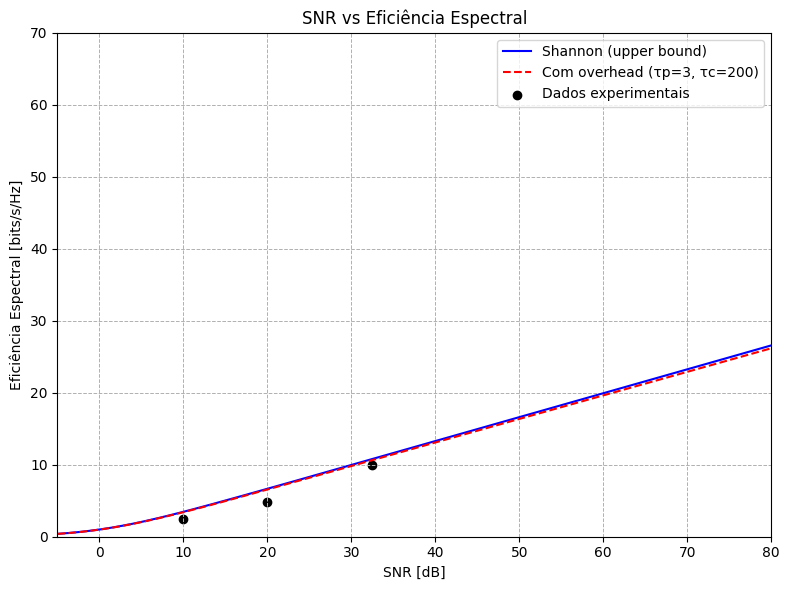

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# Intervalo de SNR em dB
snr_db = np.linspace(-5, 80, 200)   # de -5 a 40 dB
snr_lin = 10**(snr_db/10)           # converter para escala linear

# Curva de Shannon (upper bound)
se_shannon = np.log2(1 + snr_lin)

# Curva com overhead (fórmula do vosso modelo)
tau_p = 3      # número de símbolos piloto (ajustar)
tau_c = 200     # comprimento da coerência (ajustar)
overhead = 1 - (tau_p/tau_c)
se_overhead = overhead * np.log2(1 + snr_lin)

# Plot
plt.figure(figsize=(8,6))
plt.plot(snr_db, se_shannon, label="Shannon (upper bound)", color="blue")
plt.plot(snr_db, se_overhead, label=f"Com overhead (τp={tau_p}, τc={tau_c})", color="red", linestyle="--")

# Exemplo de pontos experimentais (substituir pelos vossos dados reais)
snr_exp_db = [10, 20, 32.47]             # valores medidos de SNR
se_exp = [2.5, 4.8, 9.9]                 # valores medidos de SE (exemplo)
plt.scatter(snr_exp_db, se_exp, color="black", marker="o", label="Dados experimentais")

plt.xlabel("SNR [dB]")
plt.ylabel("Eficiência Espectral [bits/s/Hz]")
plt.ylim(0, 70)
plt.xlim(-5, 80)
plt.title("SNR vs Eficiência Espectral")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()
